# Plan:
- EDA:
    - Summary overview and basic pre-processing
    - qualitative univariate
    - qualitative multivariate
    - quantitative univariate
    - quantitative multivariate
    - whole dataset

In [2]:
import pandas as pd
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from statsmodels.graphics.mosaicplot import mosaic

# Constants
SEASON = '21-22'

In [3]:
raw_player_data = pd.read_csv('../data/raw/2021-2022 Football Player Stats.csv', sep=';', encoding='latin1')
raw_player_data = raw_player_data.copy()
# raw_player_data['season'] = SEASON

invalid_character_count = raw_player_data.Player.str.contains('\\?', na=True, regex=True).sum()

if invalid_character_count > 0:
    print(f"WARNING: {invalid_character_count} `Player` values have a '?' in them.")

raw_player_data.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Max Aarons,ENG,DF,Norwich City,Premier League,22.0,2000,34,32,...,0.03,1.41,1.16,0.0,0.06,0.03,5.53,0.47,1.59,22.7
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34.0,1987,34,34,...,0.00,0.06,1.39,0.0,0.03,0.00,6.77,2.02,1.36,59.8
2,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,22.0,2000,31,29,...,0.00,0.36,1.24,0.0,0.00,0.00,8.76,0.88,0.88,50.0
3,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29.0,1993,34,34,...,0.03,0.79,2.23,0.0,0.00,0.00,8.87,0.43,0.43,50.0
4,5,Charles Abi,FRA,FW,Saint-Étienne,Ligue 1,22.0,2000,1,1,...,0.00,2.00,0.00,0.0,0.00,0.00,4.00,2.00,0.00,100.0


Some `Player` values have a question mark as a character. These are present in the underlying .csv; these will be left for the MVP, but an alternative data source for Phase2 may not have these.

In [4]:
# Rk is just an index column (sorted by last name). Names also include special characters, which will require normalisation
player_data = raw_player_data.drop('Rk', axis=1)
player_data['Player'] = player_data['Player'].apply(unidecode)

duplicate_player_count = player_data.duplicated(subset="Player").sum()
duplicates_found = duplicate_player_count > 0

if duplicates_found:
    print(f"{duplicate_player_count} duplicate Player names found.")
    duplicate_players = player_data[player_data.duplicated(subset='Player', keep=False)].sort_values(by='Player')
    display(duplicate_players)
else:
    print("No duplicates found")

136 duplicate Player names found.


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
2691,Adama Traore,ESP,FWDF,Barcelona,La Liga,26.0,1996,11,4,382,...,0.48,8.33,0.00,0.00,0.0,0.0,6.67,0.71,0.71,50.0
2692,Adama Traore,ESP,FW,Wolves,Premier League,26.0,1996,20,10,1067,...,0.76,2.35,0.76,0.00,0.0,0.0,5.38,1.01,2.18,31.6
1611,Ainsley Maitland-Niles,ENG,DF,Roma,Serie A,24.0,1997,8,7,487,...,0.19,3.52,0.56,0.00,0.0,0.0,7.59,0.93,0.74,55.6
1612,Ainsley Maitland-Niles,ENG,MF,Arsenal,Premier League,24.0,1997,8,2,268,...,0.00,0.33,1.33,0.00,0.0,0.0,12.30,1.67,1.33,55.6
563,Andrea Conti,ITA,DFMF,Sampdoria,Serie A,28.0,1994,7,2,234,...,0.38,0.00,1.54,0.00,0.0,0.0,5.38,0.00,1.54,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,Vedat Muriqi,KVX,FW,Lazio,Serie A,28.0,1994,11,1,215,...,0.42,0.42,0.00,0.42,0.0,0.0,2.92,5.42,7.50,41.9
2830,Wout Weghorst,NED,FW,Burnley,Premier League,29.0,1992,20,17,1450,...,0.56,0.50,0.75,0.00,0.0,0.0,6.02,4.10,6.65,38.2
2831,Wout Weghorst,NED,FW,Wolfsburg,Bundesliga,29.0,1992,18,17,1553,...,0.81,0.12,0.40,0.00,0.0,0.0,4.74,3.12,2.66,54.0
517,Xavier Chavalerin,FRA,MFFW,Troyes,Ligue 1,31.0,1991,34,31,2717,...,0.20,1.46,1.36,0.00,0.0,0.0,5.30,0.60,1.09,35.3


Players are duplicated when they have played for two clubs in a season.

**Options:**
1. Aggregate the metrics
2. Select only one entry (either the first or last club played-for, or the most-played for)
3. Treat both entries as separate
4. Some combination of these, accounting for league played in (e.g. aggregate if in the same league, else keep separate or select one)

**Decision:** _As we only have access to limited (one or two seasons worth of) data, we will aggregate the entries to avoid as much information loss as possible._

### Pre-Aggregation EDA on Duplicate Player Data

Before aggregating, we need to perform a quick sanity check. If a player appears twice, do their core attributes (e.g. `Nation`, `Age`, `Born`) also change?

`Nation` should rarely change (although it is possible that a player could change their declared nation).
`Age` could increment by 1, depending on how it is calculated (e.g. if it is calculated at the start of the season or at the moment of the row split).
`Born` should never change, and if so will indicate either a mistake or that they are two players with a common name.
It is unclear how `Pos` is currently calculated, or if it can change.

We will check for any variations in `Nation`, `Pos`, `Age`, and `Born` for players with multiple entries.

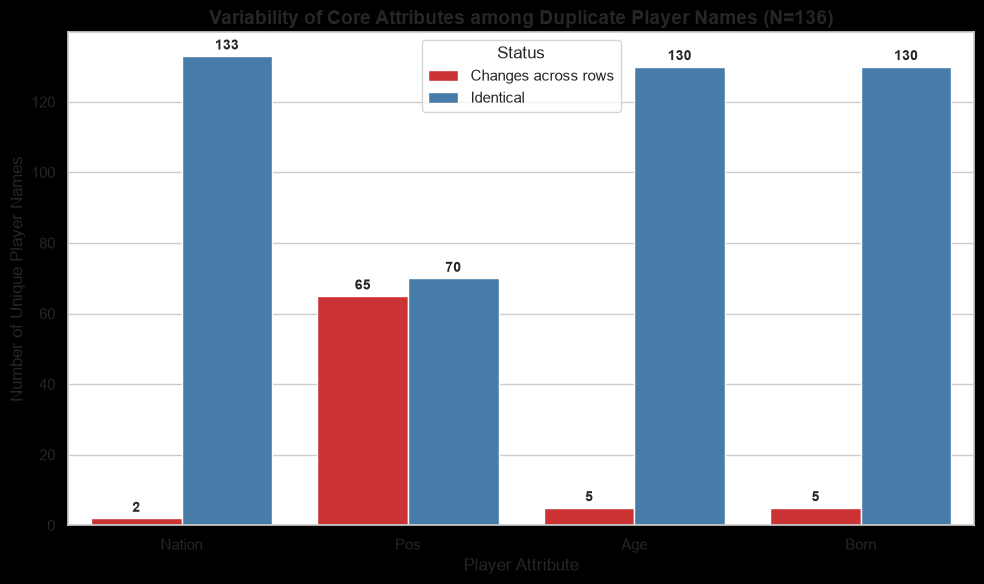

In [5]:
if duplicates_found:
    unique_counts = duplicate_players.groupby('Player')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    sns.set_theme(style='whitegrid')
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Names (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

5 Players have different Born values, suggesting these may actually be two different players with a common name.
The same is true for Age, although these are likely the same players.

In [6]:
# find Players with multiple Born values
if duplicates_found:
    born_counts = duplicate_players.groupby('Player')['Born'].nunique()
    born_collision_players = born_counts[born_counts > 1].index

    born_collisions = duplicate_players[duplicate_players['Player'].isin(born_collision_players)].sort_values(by=['Player', 'Born'])

    display(born_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
799,Ederson,BRA,GK,Manchester City,Premier League,28.0,1993
798,Ederson,BRA,MF,Salernitana,Serie A,22.0,1999
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1655,Marcelo,BRA,DF,Lyon,Ligue 1,35.0,1987
1654,Marcelo,BRA,DF,Bordeaux,Ligue 1,35.0,1987
1653,Marcelo,BRA,DF,Real Madrid,La Liga,34.0,1988
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002
2284,Rodrigo,ESP,MFFW,Leeds United,Premier League,31.0,1991


In [7]:
# find Players with different Ages, to check if they are the same
if duplicates_found:
    age_counts = duplicate_players.groupby('Player')['Age'].nunique()
    age_collision_players = age_counts[age_counts > 1].index

    age_collisions = duplicate_players[duplicate_players['Player'].isin(age_collision_players)].sort_values(by=['Player', 'Born'])

    if age_collisions.equals(born_collisions):
        print("The 'Born' overlaps are the same players as the 'Age' overlaps")

The 'Born' overlaps are the same players as the 'Age' overlaps


In [8]:
# Check the nationality overlaps
if duplicates_found:
    nation_counts = duplicate_players.groupby('Player')['Nation'].nunique()
    nation_collision_players = nation_counts[nation_counts > 1].index

    nation_collisions = duplicate_players[duplicate_players['Player'].isin(nation_collision_players)].sort_values(by=['Player', 'Born'])

    display(nation_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002


It is clear that the overlaps in Born, Age, and Nation are all due to different players sharing a common name. An identifying column can be made by combining these colums.

In [9]:
# add to the player_data dataframe as processing, and to duplicate_players for further pre-aggregating EDA

player_data['player_identifier'] = (
        player_data['Player'] + '_' + player_data['Nation'] + '_' + player_data['Born'].astype(str))

duplicate_players['player_identifier'] = (
        duplicate_players['Player'] + '_' + duplicate_players['Nation'] + '_' + duplicate_players['Born'].astype(str))


player_data[['Player', 'Nation', 'Age', 'Born', 'player_identifier']]

,Player,Nation,Age,Born,player_identifier
0,Max Aarons,ENG,22.0,2000,Max Aarons_ENG_2000
1,Yunis Abdelhamid,MAR,34.0,1987,Yunis Abdelhamid_MAR_1987
2,Salis Abdul Samed,GHA,22.0,2000,Salis Abdul Samed_GHA_2000
3,Laurent Abergel,FRA,29.0,1993,Laurent Abergel_FRA_1993
4,Charles Abi,FRA,22.0,2000,Charles Abi_FRA_2000
...,...,...,...,...,...
2916,Martin Zubimendi,ESP,23.0,1999,Martin Zubimendi_ESP_1999
2917,Szymon ?urkowski,POL,24.0,1997,Szymon ?urkowski_POL_1997
2918,Martin Odegaard,NOR,23.0,1998,Martin Odegaard_NOR_1998
2919,Milan ?uri?,BIH,32.0,1990,Milan ?uri?_BIH_1990


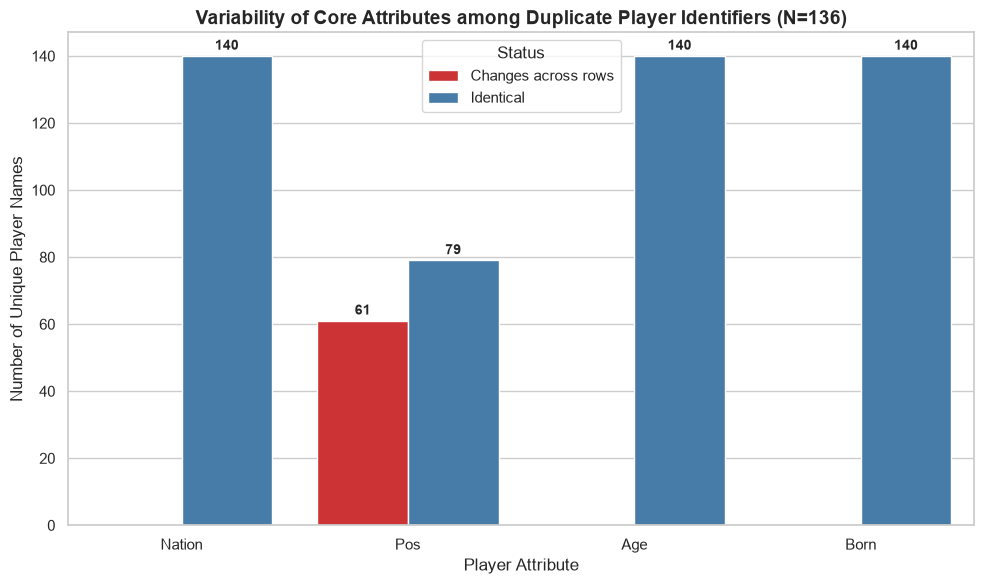

In [10]:
# Rerunning pre-aggregation checks using this new identifier:
if duplicates_found:
    unique_counts = duplicate_players.groupby('player_identifier')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Identifiers (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

These has removed the majority of the crossovers, however there are stilla  significant number (61) of duplicate players with multiple positions.

In [11]:
# find Players with multiple Pos values
if duplicates_found:
    pos_counts = duplicate_players.groupby('player_identifier')['Pos'].nunique()
    pos_collision_players = pos_counts[pos_counts > 1].index

    pos_collisions = duplicate_players[duplicate_players['player_identifier'].isin(pos_collision_players)].sort_values(by=['player_identifier', 'Born'])

    display(pos_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'player_identifier']])

,Player,Nation,Pos,Squad,Comp,Age,Born,player_identifier
2691,Adama Traore,ESP,FWDF,Barcelona,La Liga,26.0,1996,Adama Traore_ESP_1996
2692,Adama Traore,ESP,FW,Wolves,Premier League,26.0,1996,Adama Traore_ESP_1996
1611,Ainsley Maitland-Niles,ENG,DF,Roma,Serie A,24.0,1997,Ainsley Maitland-Niles_ENG_1997
1612,Ainsley Maitland-Niles,ENG,MF,Arsenal,Premier League,24.0,1997,Ainsley Maitland-Niles_ENG_1997
563,Andrea Conti,ITA,DFMF,Sampdoria,Serie A,28.0,1994,Andrea Conti_ITA_1994
...,...,...,...,...,...,...,...,...
1066,Sebastian Griesbeck,GER,MF,Union Berlin,Bundesliga,31.0,1990,Sebastian Griesbeck_GER_1990
2263,Tomas Rincon,VEN,MFFW,Torino,Serie A,34.0,1988,Tomas Rincon_VEN_1988
2264,Tomas Rincon,VEN,MF,Sampdoria,Serie A,34.0,1988,Tomas Rincon_VEN_1988
517,Xavier Chavalerin,FRA,MFFW,Troyes,Ligue 1,31.0,1991,Xavier Chavalerin_FRA_1991


'This is due to players playing a different set of positions at different clubs. This leaves 5 options:
1. Treat the entries as distinct, as different positions are likely to have different metric profiles (will lead to multiple rows for some players, overweighting them in modelling)
2. Track all the positions played across the season, however this could lead to skewed data (as different positions will naturally lead to different performance metrics, but will be collapsed)
3. Remove the players entirely from the dataset (may skew the data as high-performers may be more likely to transfer)
4. Acquire more granular position data (ideal, but outside the scope of the MVP for this project)

For the MVP, and as the player's `Pos` values are already aggregated across the dataset (i.e. players can already have multiple positions), tracking all the positions played is justified. However, acquiring more granular detail will be an important discovery step for Phase 2.

---

The final major consideration for aggregating multi-row players is how to handle multiple `Comp` and `Club` values. While these won't be included as part of the player architecture modelling, they are very likely to be relevant to player value prediction. One-hot-encoding will be required for modelling anyway, but Comp can instead be transformed to a `{Comp Name}_pct_mins`, taking the percentage of the player's minute played in each of the 5 leagues included in the dataset. In order to scale this to more leagues for future modelling, during Phase2 `Comp` can instead be replaced by some measure of league-level coefficient (e.g. UEFA coefficient for European clubs), with a weighted average being taken according to the `pct_mins` a player played in each league.

`Club` cannot be simply one-hot-encoded, as cardinality will be too high. For the MVP, club will be excluded as a modelling feature and array aggregated for post-modelling analyis only. For Phase2 club-level metrics (e.g. ELO, league finish, etc) can be used instead.

---

**Decisions:**
| Consideration | MVP Solution | Phase2 Improvement |
| ------------- | ------------ | ------------------ |
| `Pos` | Combine positions played across the season, and weighted-average (by minutes) the stats. One-hot-encode for modelling. | Acquire granular position level data (e.g. minutes player per position, or stats split by position player) |
| `Comp` | Create a column for each league, showing the percentage of minutes played in each. Exclude from clustering. | Replace Comp name from feature set with league-level data, such as coefficients. |
| `Club` | Array aggregate (as with `Pos`), but exclude from all modelling. | As with `Comp`, replace Club names with club-level metrics (ELO, league finish, etc) |

---

As per the data-dictionary.md, the other columns are counts (which can be summed to aggregate), or ratios and percentages. The latter two will need re-calculating to ensure a weighted-average. The majority of these can be recalculated from existing (summed) columns, however three cannot:
- Min% (Playing Time): Requires total team minutes which is not present in the dataset.
- On-Off (Playing Time): Requires team-level off-pitch performance stats.
- Dist (Shooting): Recalculating a true average shot distance requires individual shot distances or total shot counts/distances which are not available.

The aggregation strategy for these will be:
- Min%: Drop the column
- On-Off: Drop the column
- Dist: take a weighted average based on number of shots. e.g. (dist_at_clubA * shots_at_clubA + dist_at_clubB * shots_at_clubB)/(shots_at_clubA + shots_at_clubB)

In [12]:
# Aggregate to one row per player based on the strategy above:

player_data_clean = player_data.copy()

# estimate a weighted shot distance column
player_data_clean['ShoDist_weighted'] = player_data_clean['ShoDist'] * player_data_clean['Shots']

# split minutes played into one for each league
comps = player_data_clean['Comp'].dropna().unique()
comp_min_cols = []
for comp in comps:
    min_col = f"{comp}_pct_mins"
    player_data_clean[min_col] = player_data_clean['Min'].where(player_data_clean['Comp'] == comp, 0)
    comp_min_cols.append(min_col)

# define the aggregation strategy in a dictionary
agg_dict = {}

numeric_cols = player_data_clean.select_dtypes(include='number').columns
recalc_cols = ['90s', 'SoT%', 'G/Sh', 'G/SoT', 'PasTotCmp%', 'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 'TklDri%', 'Press%', 'DriSucc%', 'Rec%', 'AerWon%', 'ShoDist']
exclude_from_sum = recalc_cols + ['Age', 'Born']

agg_dict['Player'] = 'first'
agg_dict['Nation'] = 'first'
agg_dict['Born'] = 'first'
agg_dict['Age'] = 'max'
agg_dict['Pos'] = lambda x: ''.join(sorted(x.unique()))
agg_dict['Squad'] = lambda x: ', '.join(sorted(x.unique()))
agg_dict['Comp'] = lambda x: ', '.join(sorted(x.unique()))

for col in numeric_cols:
    if col not in exclude_from_sum:
        agg_dict[col] = 'sum'

# aggregate using the dictionary
aggregated_player_data = player_data_clean.groupby('player_identifier').agg(agg_dict)

# convert the league minutes column to a percentage of minutes played
for pct_col in comp_min_cols:
    aggregated_player_data[pct_col] = (aggregated_player_data[pct_col] / aggregated_player_data['Min']).fillna(0)

# Recalculate ratios and percentages
aggregated_player_data['90s'] = aggregated_player_data['Min'] / 90
aggregated_player_data['SoT%'] = (aggregated_player_data['SoT'] / aggregated_player_data['Shots'] * 100).fillna(0)
aggregated_player_data['G/Sh'] = (aggregated_player_data['Goals'] / aggregated_player_data['Shots']).fillna(0)
aggregated_player_data['G/SoT'] = (aggregated_player_data['Goals'] / aggregated_player_data['SoT']).fillna(0)
aggregated_player_data['PasTotCmp%'] = (aggregated_player_data['PasTotCmp'] / aggregated_player_data['PasTotAtt'] * 100).fillna(0)
aggregated_player_data['PasShoCmp%'] = (aggregated_player_data['PasShoCmp'] / aggregated_player_data['PasShoAtt'] * 100).fillna(0)
aggregated_player_data['PasMedCmp%'] = (aggregated_player_data['PasMedCmp'] / aggregated_player_data['PasMedAtt'] * 100).fillna(0)
aggregated_player_data['PasLonCmp%'] = (aggregated_player_data['PasLonCmp'] / aggregated_player_data['PasLonAtt'] * 100).fillna(0)
aggregated_player_data['TklDri%'] = (aggregated_player_data['TklDri'] / aggregated_player_data['TklDriAtt'] * 100).fillna(0)
aggregated_player_data['Press%'] = (aggregated_player_data['PresSucc'] / aggregated_player_data['Press'] * 100).fillna(0)
aggregated_player_data['DriSucc%'] = (aggregated_player_data['DriSucc'] / aggregated_player_data['DriAtt'] * 100).fillna(0)
aggregated_player_data['Rec%'] = (aggregated_player_data['Rec'] / aggregated_player_data['RecTarg'] * 100).fillna(0)
aggregated_player_data['AerWon%'] = (aggregated_player_data['AerWon'] / (aggregated_player_data['AerWon'] + aggregated_player_data['AerLost']) * 100).fillna(0)
aggregated_player_data['ShoDist'] = (aggregated_player_data['ShoDist_weighted'] / aggregated_player_data['Shots']).fillna(0)

# create the estimate for weighted average shot distance
aggregated_player_data = aggregated_player_data.drop(columns=['ShoDist_weighted'])
aggregated_player_data = aggregated_player_data.replace([np.inf, -np.inf], 0)

aggregated_player_data = aggregated_player_data.reset_index().copy()

print(f"Original shape: {player_data.shape}")
print(f"Aggregated shape: {aggregated_player_data.shape}")
aggregated_player_data.head()


Original shape: (2921, 143)
Aggregated shape: (2789, 148)


/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_1496/2797449465.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated_player_data['90s'] = aggregated_player_data['Min'] / 90
/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_1496/2797449465.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated_player_data['SoT%'] = (aggregated_player_data['SoT'] / aggregated_player_data['Shots'] * 100).fillna(0)
/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_1496/2797449465.py:45: PerformanceWar

,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,PasTotCmp%,PasShoCmp%,PasMedCmp%,PasLonCmp%,TklDri%,Press%,DriSucc%,Rec%,AerWon%,ShoDist
0,?tefan Radu_ROU_1986,?tefan Radu,ROU,1986,35.0,DF,Lazio,Serie A,10,6,...,81.939163,91.428571,83.673469,50.000000,33.103448,32.694476,66.666667,95.969773,54.263566,23.9
1,?ukasz Fabia?ski_POL_1985,?ukasz Fabia?ski,POL,1985,37.0,GK,West Ham,Premier League,37,37,...,63.235294,100.000000,99.018003,47.789474,0.000000,100.000000,0.000000,99.107143,0.000000,0.0
2,?ukasz Skorupski_POL_1991,?ukasz Skorupski,POL,1991,31.0,GK,Bologna,Serie A,36,36,...,74.857143,98.507463,98.165138,55.555556,0.000000,21.428571,0.000000,99.393939,0.000000,0.0
3,Aaron Connolly_IRL_2000,Aaron Connolly,IRL,2000,22.0,FW,Brighton,Premier League,4,1,...,83.207547,81.761978,85.679612,0.000000,0.000000,18.490566,0.000000,33.769634,0.000000,14.9
4,Aaron Cresswell_ENG_1989,Aaron Cresswell,ENG,1989,32.0,DF,West Ham,Premier League,31,31,...,80.177515,92.720307,88.345865,46.904762,51.685393,31.436700,23.255814,96.215139,54.587156,19.9


In [13]:
remaining_dupes = aggregated_player_data[aggregated_player_data.player_identifier.isin(duplicate_players.player_identifier)]
duplicate_player_count = remaining_dupes.duplicated(subset="player_identifier").sum()

print(f"{duplicate_player_count} duplicate players remaining")

0 duplicate players remaining


### EDA

In [14]:
qualitative_columns = list(aggregated_player_data.select_dtypes(include='string').columns)
quantitative_columns = list(aggregated_player_data.select_dtypes(include='number').columns)

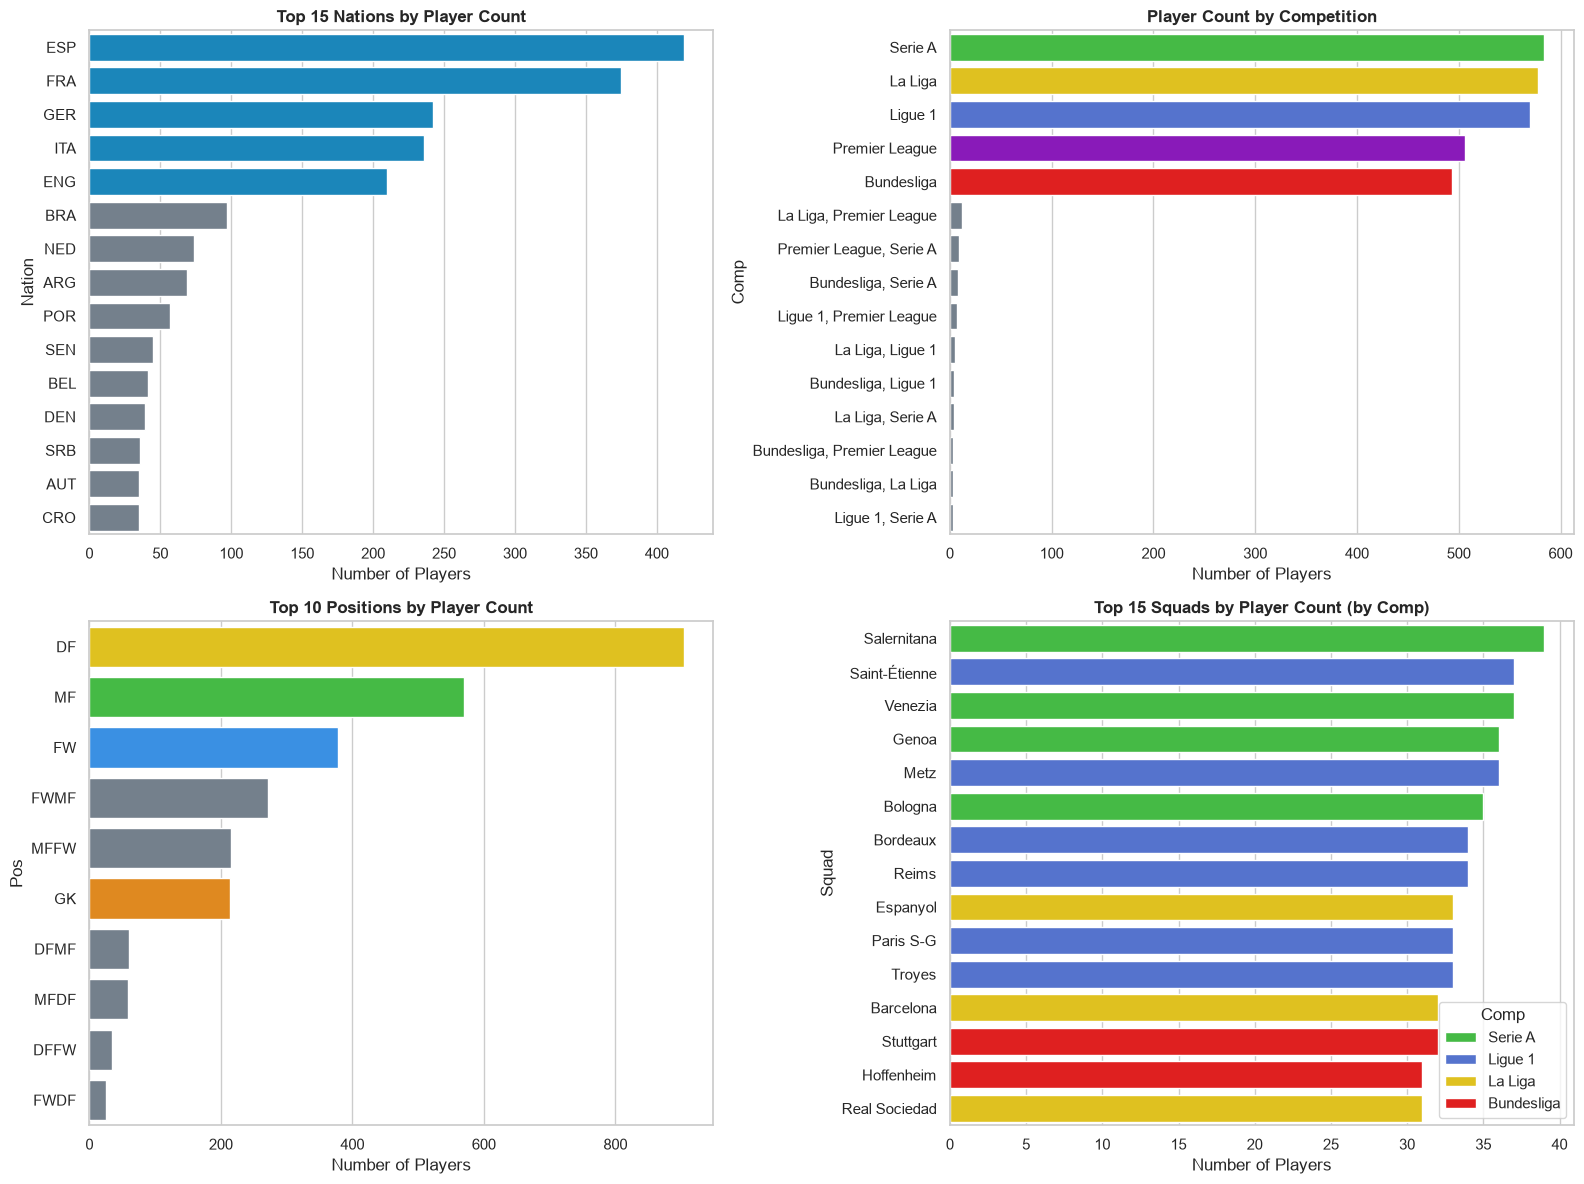

In [15]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Target top 5 nations
target_nations = {"ESP", "FRA", "GER", "ITA", "ENG"}

# ---------------------------------------------------------
# 1. Top 15 Nations by Player Count (Conditional Blue/Red)
# ---------------------------------------------------------
top_nations = aggregated_player_data["Nation"].value_counts().head(15)
nation_colors = {
    nation: "#008fd5" if nation in target_nations else "slategrey"
    for nation in top_nations.index
}

sns.barplot(
    x=top_nations.values,
    y=top_nations.index,
    hue=top_nations.index,
    palette=nation_colors,
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "Top 15 Nations by Player Count", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 2. Player Count by Competition (Custom Palette with Fallback)
# ---------------------------------------------------------
# Define custom colors for competitions (add your specific values here)
comp_palette_map = {
    "Premier League": "darkviolet",
    "La Liga": "gold",
    "Bundesliga": "red",
    "Serie A": "limegreen",
    "Ligue 1": "royalblue",
}

comp_counts = aggregated_player_data["Comp"].value_counts()
comp_colors = {
    comp: comp_palette_map.get(comp, "slategrey") for comp in comp_counts.index
}

sns.barplot(
    x=comp_counts.values,
    y=comp_counts.index,
    hue=comp_counts.index,
    palette=comp_colors,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    "Player Count by Competition", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 3. Top 10 Positions (Custom Palette with Fallback)
# ---------------------------------------------------------
# Define custom colors for positions (add your specific values here)
pos_palette_map = {
    "DF": "gold",
    "MF": "limegreen",
    "FW": "dodgerblue",
    "GK": "darkorange",
}

top_pos = aggregated_player_data["Pos"].value_counts().head(10)
pos_colors = {
    pos: pos_palette_map.get(pos, "slategrey") for pos in top_pos.index
}

sns.barplot(
    x=top_pos.values,
    y=top_pos.index,
    hue=top_pos.index,
    palette=pos_colors,
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    "Top 10 Positions by Player Count", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 4. Top 15 Squads Colored by Competition
# ---------------------------------------------------------
top_squad_names = (
    aggregated_player_data["Squad"].value_counts().head(15).index
)

# Filter dataset to top 15 squads and aggregate count per Squad and Comp
top_squads_df = (
    aggregated_player_data[
        aggregated_player_data["Squad"].isin(top_squad_names)
    ]
    .groupby(["Squad", "Comp"])
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
)

sns.barplot(
    data=top_squads_df,
    x="Count",
    y="Squad",
    hue="Comp",
    palette=comp_colors,  # Reuses competition color map from Chart 2
    dodge=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "Top 15 Squads by Player Count (by Comp)", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("Number of Players")

plt.tight_layout()
plt.show()

In [16]:
categories = {
    "Nation": "Top 5 Nations",
    "Comp": "Top 5 Competitions",
    "Pos": "Top 5 Positions",
    "Squad": "Top 5 Squads",
}

for col, title in categories.items():
    counts = aggregated_player_data[col].value_counts().head(5)
    total_valid = aggregated_player_data[col].count()

    summary_df = pd.DataFrame(
        {
            col: counts.index,
            "Count": counts.values,
            "Percentage (%)": ((counts.values / total_valid) * 100).round(2),
        }
    )

    print(f"\n{'='*15} {title} {'='*15}")
    print(summary_df.to_string(index=False))


=============== Top 5 Nations ===============
Nation  Count  Percentage (%)
   ESP    419           15.02
   FRA    375           13.45
   GER    242            8.68
   ITA    236            8.46
   ENG    210            7.53

=============== Top 5 Competitions ===============
          Comp  Count  Percentage (%)
       Serie A    584           20.94
       La Liga    578           20.72
       Ligue 1    570           20.44
Premier League    506           18.14
    Bundesliga    493           17.68

=============== Top 5 Positions ===============
 Pos  Count  Percentage (%)
  DF    904           32.41
  MF    569           20.40
  FW    378           13.55
FWMF    272            9.75
MFFW    216            7.74

=============== Top 5 Squads ===============
        Squad  Count  Percentage (%)
  Salernitana     39            1.40
Saint-Étienne     37            1.33
      Venezia     37            1.33
        Genoa     36            1.29
         Metz     36            1.29


**Findings:**

There are far more Spanish and French players in Europe's top 5 leagues than other nationalities. Some way behind these are Germany, Italy, and England, before another significant drop off to other nationalities. Brazil, Argentina and Senegal are the only non-European nations in the Top 15.

Serie A, La Liga and Ligue 1 have the most players. Bundesliga unsurprisingly has the least (due to only having 18 clubs in the league), but the Premier League surprisingly only has slightly more. Only a small proportion of players have played in multiple leagues in the season, with La liga to Premier League being the most common switch.

32% of players are defenders, with 20% pure midfielders, 19% midfields AND forwards, 14% just forwards, and only 8% goalkeepers.

Italian and French clubs dominate the top squads by player count, with Paris and Barcelona the only highest-level clubs that stand out in the top 15.

,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,PasShoCmp%,PasMedCmp%,PasLonCmp%,TklDri%,Press%,DriSucc%,Rec%,AerWon%,ShoDist,Num_Pos
1340,Josep Martinez_ESP_1998,Josep Martinez,ESP,1998,24.0,GK,RB Leipzig,Bundesliga,1,1,...,100.000000,100.000000,66.666667,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,1
1074,Isco_ESP_1992,Isco,ESP,1992,30.0,"FW, MF",Real Madrid,La Liga,13,2,...,91.538462,93.690852,74.825175,25.000000,29.320000,73.400000,92.872340,33.333333,14.700000,2
386,Caio Henrique Oliveira Silva_BRA_1997,Caio Henrique Oliveira Silva,BRA,1997,24.0,DF,Monaco,Ligue 1,34,31,...,90.204082,80.842912,43.557692,44.444444,32.857143,34.375000,89.591837,30.985915,21.300000,1
1666,Makoto Hasebe_JPN_1984,Makoto Hasebe,JPN,1984,38.0,DF,Eint Frankfurt,Bundesliga,18,12,...,92.485549,90.988372,75.280899,57.075472,38.148148,66.666667,97.565543,50.000000,0.000000,1
1841,Mattia Zaccagni_ITA_1995,Mattia Zaccagni,ITA,1995,26.0,"FW, MF","Hellas Verona, Lazio",Serie A,31,23,...,90.600522,75.200000,64.285714,25.118483,25.568627,52.849003,79.560440,66.281755,15.236893,2


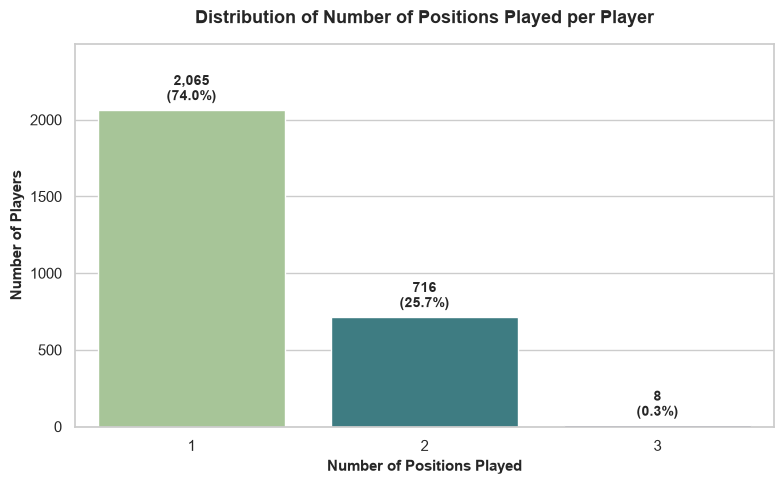

In [17]:
def clean_positions(pos_str):
  if not isinstance(pos_str, str) or pd.isna(pos_str):
      return ""
# Keep only alphabetical characters
  clean_str = "".join([c for c in pos_str if c.isalpha()])
# Chunk into 2-letter position codes (e.g., 'MFDFDF' -> ['MF', 'DF', 'DF'])
  chunks = [clean_str[i:i+2] for i in range(0, len(clean_str), 2) if len(clean_str[i:i+2]) == 2]
# Deduplicate and sort alphabetically
  unique_sorted = sorted(list(set(chunks)))
  return ", ".join(unique_sorted)

# Apply position cleanup to the dataset
aggregated_player_data['Pos'] = aggregated_player_data['Pos'].apply(clean_positions)

# Count the number of different positions played by each player (e.g., 'DF, MF' -> 2)
aggregated_player_data['Num_Pos'] = aggregated_player_data['Pos'].apply(lambda x: len(x.split(', ')) if x else 0)

display(aggregated_player_data.sample(5))

fig, ax = plt.subplots(figsize=(8, 5))

# Plot total counts for each number of positions played
ax = sns.countplot(
    data=aggregated_player_data,
    x="Num_Pos",
    hue="Num_Pos",
    palette="crest",
)

# Remove the redundant legend generated by hue
if ax.get_legend():
    ax.get_legend().remove()

# Calculate total non-zero/valid entries for percentages
total_players = len(aggregated_player_data)

# Add count and percentage annotations above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_players) * 100
        ax.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

ax.set_title(
    "Distribution of Number of Positions Played per Player",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Positions Played", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Players", fontsize=11, fontweight="bold")

# Expand top y-limit to prevent annotation cutoff
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], ylim[1] * 1.15)

plt.tight_layout()
plt.show()

In [18]:
aggregated_player_data[aggregated_player_data.Num_Pos > 2]

,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,PasShoCmp%,PasMedCmp%,PasLonCmp%,TklDri%,Press%,DriSucc%,Rec%,AerWon%,ShoDist,Num_Pos
226,Ansgar Knauff_GER_2002,Ansgar Knauff,GER,2002,20.0,"DF, FW, MF","Dortmund, Eint Frankfurt",Bundesliga,17,8,...,74.350649,61.468971,44.847605,28.528529,30.000000,42.239186,77.641278,26.705370,18.625000,3
342,Bilal Brahimi_FRA_2000,Bilal Brahimi,FRA,2000,22.0,"DF, FW, MF","Angers, Nice",Ligue 1,20,5,...,84.232082,71.857708,46.532847,50.476190,27.679083,54.864865,68.543689,32.686084,16.348221,3
1019,Hugo Duro_ESP_1999,Hugo Duro,ESP,1999,22.0,"DF, FW, MF","Getafe, Valencia",La Liga,31,22,...,92.990033,89.646621,40.909091,27.551020,19.269663,54.237288,81.400689,46.480994,15.675093,3
1153,Jason_ESP_1994,Jason,ESP,1994,27.0,"DF, FW, MF","Alavés, Valencia",La Liga,19,11,...,83.015955,80.818302,46.769912,13.913043,16.739563,30.573248,74.117647,33.381295,22.845946,3
1705,Marcel Sabitzer_AUT_1994,Marcel Sabitzer,AUT,1994,28.0,"DF, FW, MF","Bayern Munich, RB Leipzig",Bundesliga,27,8,...,89.480355,89.511754,66.039572,66.741071,34.316547,84.000000,91.933333,42.458101,25.262585,3
1868,Maxwel Cornet_CIV_1996,Maxwel Cornet,CIV,1996,25.0,"DF, FW, MF","Burnley, Lyon","Ligue 1, Premier League",27,22,...,84.973822,89.650037,24.878049,33.608247,20.140845,40.980392,74.126638,28.977273,16.600000,3
2117,Panagiotis Retsos_GRE_1998,Panagiotis Retsos,GRE,1998,23.0,"DF, FW, MF","Hellas Verona, Leverkusen","Bundesliga, Serie A",9,1,...,78.909091,62.773973,77.733333,0.000000,30.566667,100.000000,96.761905,100.000000,8.200000,3
2733,Xavier Chavalerin_FRA_1991,Xavier Chavalerin,FRA,1991,31.0,"DF, FW, MF","Reims, Troyes",Ligue 1,37,33,...,88.125000,80.451128,62.191104,26.347305,33.076923,74.482759,85.588235,31.086957,18.767094,3


**Findings:**
The majority of players are only given one (admittedly broad) position, with only 25.7% playing two, and just 0.3% (8 players, above) playing all three outfield position groups.

In [19]:
# Perform a Chi-squared test to check for independence between the nations represented and each league
# Excluding the 5 Nations that the league's themselves are in

df_exploded = aggregated_player_data[
    ['player_identifier', 'Nation', 'Comp']
].copy()
df_exploded = df_exploded[
    ~df_exploded.Nation.isin(['ENG', 'GER', 'FRA', 'ESP', 'ITA'])
]

df_exploded['Nation'] = df_exploded['Nation'].str.split(', ')
df_exploded = df_exploded.explode('Nation')
df_exploded['Comp'] = df_exploded['Comp'].str.split(', ')
df_exploded = df_exploded.explode('Comp')

# Get Top 15 nations
top_15_nations = df_exploded['Nation'].value_counts().head(15).index
df_filtered = df_exploded[df_exploded['Nation'].isin(top_15_nations)].copy()
df_filtered = df_filtered.reset_index(drop=True)

# Sort for consistent ordering in plots
df_filtered = df_filtered.sort_values(by=['Nation', 'Comp'])

# 2. Chi-Squared Test of Independence
contingency_table = pd.crosstab(df_filtered['Nation'], df_filtered['Comp'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# Calculate Pearson Residuals
residuals = (contingency_table - expected) / np.sqrt(expected)

# --- NEW: Build Annotation Matrix for Heatmap (Residual + Count) ---
annot_matrix = pd.DataFrame(
    '', index=residuals.index, columns=residuals.columns
)
for r in residuals.index:
  for c in residuals.columns:
    count = contingency_table.loc[r, c]
    res_val = residuals.loc[r, c]
    annot_matrix.loc[r, c] = f'{res_val:.2f}\n({count})'

print('--- Chi-Squared Test Results ---')
print(f'Chi-squared Statistic: {chi2:.4f}')
print(f'p-value: {p_val:.4e}')
print(f'Degrees of Freedom: {dof}')
print('\nSignificance:')
if p_val < 0.05:
  print(
      'Statistically Significant (p < 0.05). Nations are NOT distributed'
      ' proportionally across leagues.'
  )
else:
  print(
      'Not Statistically Significant (p >= 0.05). Nations are distributed'
      ' proportionally across leagues.'
  )

--- Chi-Squared Test Results ---
Chi-squared Statistic: 339.8055
p-value: 2.9187e-42
Degrees of Freedom: 56

Significance:
Statistically Significant (p < 0.05). Nations are NOT distributed proportionally across leagues.


/Users/Scott.Trowers/Documents/player_architect_analysis/.venv/lib/python3.14/site-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


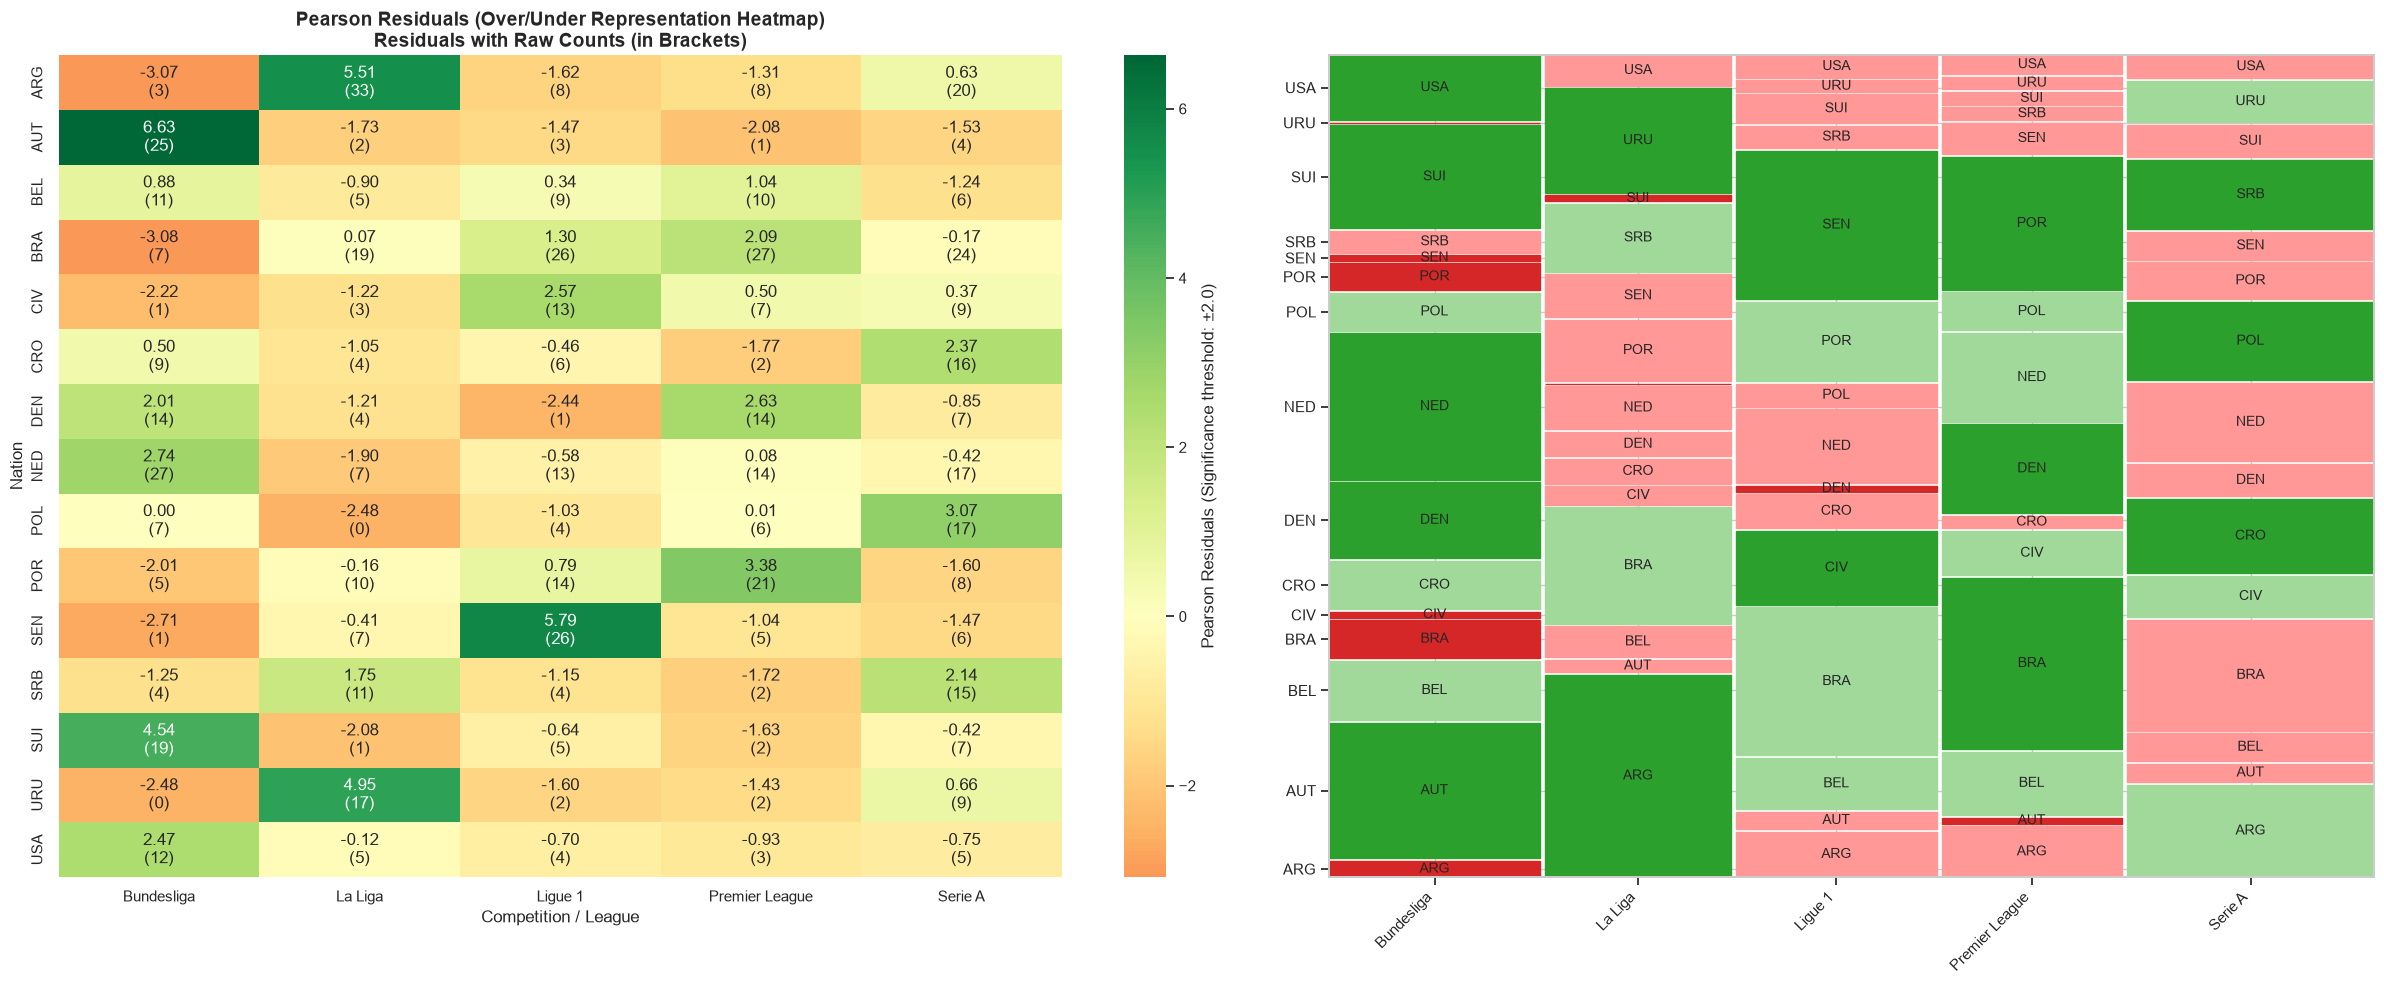

In [20]:
fig = plt.figure(figsize=(24, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# Plot A: Residual Heatmap with Counts
ax_heatmap = fig.add_subplot(gs[0, 0])
sns.heatmap(
    residuals,
    annot=annot_matrix,  # Custom string matrix with count in brackets
    fmt='',  # Disable default numeric formatting
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Pearson Residuals (Significance threshold: ±2.0)'},
    ax=ax_heatmap,
)
ax_heatmap.set_title(
    'Pearson Residuals (Over/Under Representation Heatmap)\nResiduals with'
    ' Raw Counts (in Brackets)',
    fontsize=14,
    fontweight='bold',
)
ax_heatmap.set_xlabel('Competition / League')
ax_heatmap.set_ylabel('Nation')

# Plot B: Mosaic Plot (Flipped: Comp on x-axis, Nation on y-axis)
ax_mosaic = fig.add_subplot(gs[0, 1])


def cell_properties(key):
  # key is now a tuple: (Comp, Nation)
  comp, nation = key
  if nation in residuals.index and comp in residuals.columns:
    res = residuals.loc[nation, comp]
    if res > 2.0:
      color = (
          '#2ca02c'  # Statistically significant over-representation (Dark Green)
      )
    elif res < -2.0:
      color = (
          '#d62728'  # Statistically significant under-representation (Dark Red)
      )
    elif res > 0:
      color = (
          '#a1d99b'  # Mild/non-significant over-representation (Light Green)
      )
    else:
      color = '#ff9896'  # Mild/non-significant under-representation (Light Red)
  else:
    color = '#f0f0f0'
  return {'color': color, 'edgecolor': 'white'}


def cell_labelizer(key):
  # key is (Comp, Nation) -> return only the nation name
  comp, nation = key
  if nation in contingency_table.index and comp in contingency_table.columns:
    # Only label non-zero cells to avoid clutter
    if contingency_table.loc[nation, comp] > 0:
      return nation
  return ''


# Create Mosaic Plot using statsmodels with ['Comp', 'Nation'] order
mosaic(
    df_filtered,
    ['Comp', 'Nation'],
    properties=cell_properties,
    labelizer=cell_labelizer,  # Custom labelizer showing only nation names
    ax=ax_mosaic,
)

# Rotate labels on mosaic plot for legibility
plt.setp(ax_mosaic.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Findings:**

Even excluding the nations that are home to the top 5 leagues, the nations represented are not independent of the league.
- In the Bundesliga, Austrian and Swiss Players in particular are over-represented vs the other Top 5 leagues, while South Americans (from Argentina, Brazil, and Uruguay) are the most under-represented.
- Conversely, Argentineans and Uruguayans are significantly over-represented in La Liga
- Senegalese and Ivorians are the over-represented in Ligue 1
- The Premier League and Serie A has fewer extremes.
- However, Portuguese, Danish, and Brazilian players are over-represented in the former, with Polish, Croatian, and Serbian players over-represented in Serie A.

### Qualitative EDA

The majority of metrics are raw counts, which can be skewed simply by playing time (e.g., a player who plays twice as many minutes may have more total passes than a player who has had limited playtime but makes far more passes per game). These counts can therefore be normalised by calculating the 'per 90 min' equivalents. Ratios, Percentages, and already-calculated-averages (e.g goals-per-shot) do not require further normalisation.

In [21]:
columns_to_normalise = [
       'Goals', 'Shots', 'SoT', 'ShoFK', 'ShoPK', 'PKatt', 'PasTotCmp', 'PasTotAtt',
       'PasTotDist', 'PasTotPrgDist', 'PasShoCmp', 'PasShoAtt', 'PasMedCmp', 'PasMedAtt',
       'PasLonCmp', 'PasLonAtt', 'Assists', 'PasAss', 'Pas3rd', 'PPA', 'CrsPA',
       'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'TB', 'PasPress', 'Sw',
       'PasCrs', 'CK', 'CkIn', 'CkOut', 'CkStr', 'PasGround', 'PasLow', 'PasHigh',
       'PaswLeft', 'PaswRight', 'PaswHead', 'TI', 'PaswOther', 'PasCmp', 'PasOff',
       'PasOut', 'PasInt', 'PasBlocks', 'SCA', 'ScaPassLive', 'ScaPassDead', 'ScaDrib',
       'ScaSh', 'ScaFld', 'ScaDef', 'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib',
       'GcaSh', 'GcaFld', 'GcaDef', 'Tkl', 'TklWon', 'TklDef3rd', 'TklMid3rd',
       'TklAtt3rd', 'TklDri', 'TklDriAtt', 'TklDriPast', 'Press', 'PresSucc',
       'PresDef3rd', 'PresMid3rd', 'PresAtt3rd', 'Blocks', 'BlkSh', 'BlkShSv',
       'BlkPass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Touches', 'TouDefPen', 'TouDef3rd',
       'TouMid3rd', 'TouAtt3rd', 'TouAttPen', 'TouLive', 'DriSucc', 'DriAtt',
       'DriPast', 'DriMegs', 'Carries', 'CarTotDist', 'CarPrgDist', 'CarProg',
       'Car3rd', 'CPA', 'CarMis', 'CarDis', 'RecTarg', 'Rec', 'RecProg', 'CrdY',
       'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'TklW', 'PKwon', 'PKcon',
       'OG', 'Recov', 'AerWon', 'AerLost'
   ]

player_data_p90 = aggregated_player_data.copy()

for raw_col_name in columns_to_normalise:
    new_col_name = f"{raw_col_name}_p90"

    player_data_p90[new_col_name] = player_data_p90[raw_col_name] / player_data_p90['90s']

    player_data_p90.drop(raw_col_name, axis=1, inplace=True)

player_data_p90 = player_data_p90.copy()

player_data_p90.head()

/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_1496/16379186.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_data_p90[new_col_name] = player_data_p90[raw_col_name] / player_data_p90['90s']


,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,Fld_p90,Off_p90,Crs_p90,TklW_p90,PKwon_p90,PKcon_p90,OG_p90,Recov_p90,AerWon_p90,AerLost_p90
0,?tefan Radu_ROU_1986,?tefan Radu,ROU,1986,35.0,DF,Lazio,Serie A,10,6,...,0.157014,0.000000,0.182914,0.131115,0.0,0.000000,0.0,1.252878,0.339928,0.286511
1,?ukasz Fabia?ski_POL_1985,?ukasz Fabia?ski,POL,1985,37.0,GK,West Ham,Premier League,37,37,...,0.005135,0.000000,0.000000,0.000000,0.0,0.000811,0.0,0.103784,0.000000,0.000000
2,?ukasz Skorupski_POL_1991,?ukasz Skorupski,POL,1991,31.0,GK,Bologna,Serie A,36,36,...,0.004722,0.000000,0.000000,0.000000,0.0,0.001667,0.0,0.125000,0.000000,0.000833
3,Aaron Connolly_IRL_2000,Aaron Connolly,IRL,2000,22.0,FW,Brighton,Premier League,4,1,...,2.376923,0.000000,0.340385,0.000000,0.0,0.000000,0.0,2.376923,0.000000,2.376923
4,Aaron Cresswell_ENG_1989,Aaron Cresswell,ENG,1989,32.0,DF,West Ham,Premier League,31,31,...,0.014197,0.002311,0.068672,0.020800,0.0,0.000990,0.0,0.264784,0.039288,0.032685


Now stats are all normalised as per-90-minutes, averages, or ratio metrics, comparisons between players are more robust.

The remaining features can now be explored.

There are 141 metrics in the dataset; far too many to explore one by one, or all at once. However, these metrics can broadly be categorised (see the data-dictionary.md for these categories).

In [29]:
metrics = set(player_data_p90.select_dtypes(include='number').columns).difference(set(['Age', 'Born']))

len(metrics)

141

In [30]:
list(player_data_p90.columns)


['player_identifier',
 'Player',
 'Nation',
 'Born',
 'Age',
 'Pos',
 'Squad',
 'Comp',
 'MP',
 'Starts',
 'Min',
 'Premier League_pct_mins',
 'Ligue 1_pct_mins',
 'Bundesliga_pct_mins',
 'Serie A_pct_mins',
 'La Liga_pct_mins',
 '90s',
 'SoT%',
 'G/Sh',
 'G/SoT',
 'PasTotCmp%',
 'PasShoCmp%',
 'PasMedCmp%',
 'PasLonCmp%',
 'TklDri%',
 'Press%',
 'DriSucc%',
 'Rec%',
 'AerWon%',
 'ShoDist',
 'Num_Pos',
 'Goals_p90',
 'Shots_p90',
 'SoT_p90',
 'ShoFK_p90',
 'ShoPK_p90',
 'PKatt_p90',
 'PasTotCmp_p90',
 'PasTotAtt_p90',
 'PasTotDist_p90',
 'PasTotPrgDist_p90',
 'PasShoCmp_p90',
 'PasShoAtt_p90',
 'PasMedCmp_p90',
 'PasMedAtt_p90',
 'PasLonCmp_p90',
 'PasLonAtt_p90',
 'Assists_p90',
 'PasAss_p90',
 'Pas3rd_p90',
 'PPA_p90',
 'CrsPA_p90',
 'PasProg_p90',
 'PasAtt_p90',
 'PasLive_p90',
 'PasDead_p90',
 'PasFK_p90',
 'TB_p90',
 'PasPress_p90',
 'Sw_p90',
 'PasCrs_p90',
 'CK_p90',
 'CkIn_p90',
 'CkOut_p90',
 'CkStr_p90',
 'PasGround_p90',
 'PasLow_p90',
 'PasHigh_p90',
 'PaswLeft_p90',
 'Pasw

In [28]:
# Column names by category

matches_played_cols = ['MP', 'Starts', 'Min', '90s']
league_playtime_cols = ['Premier League_pct_mins', 'Ligue 1_pct_mins', 'Bundesliga_pct_mins', 'Serie A_pct_mins', 'La Liga_pct_mins']
finishing_cols = ['SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'Goals_p90', 'Shots_p90', 'SoT_p90']
set_pieces_cols = ['ShoFK_p90', 'ShoPK_p90', 'PKatt_p90', 'PasDead_p90', 'PasFK_p90', 'CK_p90', 'CkIn_p90', 'CkOut_p90', 'CkStr_p90', 'TI_p90', 'ScaPassDead_p90', 'GcaPassDead_p90']
chance_creation_cols = ['Assists_p90', 'PasAss_p90', 'SCA_p90', 'ScaPassLive_p90', 'ScaDrib_p90', 'ScaSh_p90', 'ScaFld_p90', 'ScaDef_p90', 'GCA_p90', 'GcaPassLive_p90', 'GcaDrib_p90', 'GcaSh_p90', 'GcaFld_p90', 'GcaDef_p90', 'PKwon_p90']
passing_cols = ['PasTotCmp%', 'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 'PasTotCmp_p90', 'PasTotAtt_p90', 'PasTotDist_p90', 'PasTotPrgDist_p90', 'PasShoCmp_p90', 'PasShoAtt_p90', 'PasMedCmp_p90', 'PasMedAtt_p90', 'PasLonCmp_p90', 'PasLonAtt_p90',
'Pas3rd_p90', 'PPA_p90', 'CrsPA_p90', 'PasProg_p90', 'PasAtt_p90', 'PasLive_p90', 'TB_p90', 'PasPress_p90', 'Sw_p90', 'PasCrs_p90', 'PasGround_p90', 'PasLow_p90', 'PasHigh_p90', 'PaswLeft_p90', 'PaswRight_p90', 'PaswHead_p90', 'PaswOther_p90', 'PasCmp_p90',
'PasOut_p90', 'PasInt_p90', 'PasBlocks_p90', 'RecProg_p90', 'Crs_p90']
positioning_cols = ['PasOff_p90', 'Off_p90']
defensive_plays_cols = ['TklDri%', 'Tkl_p90', 'TklWon_p90', 'TklDef3rd_p90', 'TklMid3rd_p90', 'TklAtt3rd_p90', 'TklDri_p90', 'TklDriAtt_p90', 'TklDriPast_p90', 'Blocks_p90', 'BlkSh_p90', 'BlkShSv_p90', 'BlkPass_p90', 'Int_p90', 'Tkl+Int_p90', 'Clr_p90',
'Err_p90', 'TklW_p90', 'PKcon_p90', 'OG_p90', 'Recov_p90']
pressures_cols = ['Press%', 'Press_p90', 'PresSucc_p90', 'PresDef3rd_p90', 'PresMid3rd_p90', 'PresAtt3rd_p90']
involvement_cols = ['Rec%', 'Touches_p90', 'TouDefPen_p90', 'TouDef3rd_p90', 'TouMid3rd_p90', 'TouAtt3rd_p90', 'TouAttPen_p90', 'TouLive_p90', 'RecTarg_p90', 'Rec_p90']
dribbling_cols = ['DriSucc%', 'DriSucc_p90', 'DriAtt_p90', 'DriPast_p90', 'DriMegs_p90', 'Carries_p90', 'CarTotDist_p90', 'CarPrgDist_p90', 'CarProg_p90', 'Car3rd_p90', 'CPA_p90', 'CarMis_p90', 'CarDis_p90', 'Fld_p90']
discipline_cols = ['CrdY_p90', 'CrdR_p90', '2CrdY_p90', 'Fls_p90']
aerial_ability_cols = ['AerWon%', 'AerWon_p90', 'AerLost_p90']
